# Baseline model predykcji ceny samochodu

Notebook przygotowany do **punktu 2 wymagań projektu**: wersja podstawowa modelu.

Zakres:
- wybór problemu ML,
- EDA,
- preprocessing,
- trening modelu bazowego,
- ewaluacja.

Problem: **regresja** - przewidywanie ceny samochodu na podstawie danych z ogłoszeń.
Target modelu: `Log_Price`, czyli logarytm ceny `Price`.

## 1. Import bibliotek i konfiguracja

In [16]:
from pathlib import Path
import ast

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.ensemble import HistGradientBoostingRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer

RANDOM_STATE = 42
DATA_PATH = Path("../data/raw/Car_sale_ads.csv")
if not DATA_PATH.exists():
    DATA_PATH = Path("data/raw/Car_sale_ads.csv")

pd.set_option("display.max_columns", 120)

## 2. Wczytanie danych

In [17]:
df = pd.read_csv(DATA_PATH)
print(f"Liczba rekordów: {df.shape[0]}")
print(f"Liczba kolumn: {df.shape[1]}")
df.head()

Liczba rekordów: 208304
Liczba kolumn: 25


,Index,Price,Currency,Condition,Vehicle_brand,Vehicle_model,Vehicle_version,Vehicle_generation,Production_year,Mileage_km,Power_HP,Displacement_cm3,Fuel_type,CO2_emissions,Drive,Transmission,Type,Doors_number,Colour,Origin_country,First_owner,First_registration_date,Offer_publication_date,Offer_location,Features
0,0,86200,PLN,New,Abarth,595,NaN,NaN,2021,1.0,145.0,1400.0,Gasoline,NaN,Front wheels,Manual,small_cars,3.0,gray,NaN,NaN,NaN,04/05/2021,"ul. Jubilerska 6 - 04-190 Warszawa, Mazowiecki...",[]
1,1,43500,PLN,Used,Abarth,Other,NaN,NaN,1974,59000.0,75.0,1100.0,Gasoline,NaN,Front wheels,Manual,coupe,2.0,silver,NaN,NaN,NaN,03/05/2021,"kanonierska12 - 04-425 Warszawa, Rembertów (Po...",[]
2,2,44900,PLN,Used,Abarth,500,NaN,NaN,2018,52000.0,180.0,1368.0,Gasoline,NaN,NaN,Automatic,small_cars,3.0,silver,NaN,NaN,NaN,03/05/2021,"Warszawa, Mazowieckie, Białołęka","['ABS', 'Electric front windows', 'Drivers air..."
3,3,39900,PLN,Used,Abarth,500,NaN,NaN,2012,29000.0,160.0,1368.0,Gasoline,139.0,Front wheels,Manual,small_cars,3.0,gray,NaN,NaN,NaN,30/04/2021,"Jaworzno, Śląskie","['ABS', 'Electric front windows', 'Drivers air..."
4,4,97900,PLN,New,Abarth,595,NaN,NaN,2021,600.0,165.0,1368.0,Gasoline,NaN,NaN,Manual,small_cars,3.0,blue,NaN,NaN,NaN,30/04/2021,"ul. Gorzysława 9 - 61-057 Poznań, Nowe Miasto ...","['ABS', 'Electrically adjustable mirrors', 'Pa..."


## 3. EDA - eksploracja danych

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 208304 entries, 0 to 208303
Data columns (total 25 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Index                    208304 non-null  int64  
 1   Price                    208304 non-null  int64  
 2   Currency                 208304 non-null  object 
 3   Condition                208304 non-null  object 
 4   Vehicle_brand            208304 non-null  object 
 5   Vehicle_model            208304 non-null  object 
 6   Vehicle_version          138082 non-null  object 
 7   Vehicle_generation       147860 non-null  object 
 8   Production_year          208304 non-null  int64  
 9   Mileage_km               207321 non-null  float64
 10  Power_HP                 207661 non-null  float64
 11  Displacement_cm3         206338 non-null  float64
 12  Fuel_type                208304 non-null  object 
 13  CO2_emissions            94047 non-null   float64
 14  Driv

In [19]:
df["Price"].describe()

count    2.083040e+05
mean     6.305383e+04
std      8.665967e+04
min      5.000000e+02
25%      1.780000e+04
50%      3.570000e+04
75%      7.599000e+04
max      6.999000e+06
Name: Price, dtype: float64

In [20]:
missing = (df.isna().mean() * 100).sort_values(ascending=False).round(2)
missing.head(15).to_frame("missing_percent")

,missing_percent
First_owner,68.75
First_registration_date,58.50
CO2_emissions,54.85
Origin_country,43.20
Vehicle_version,33.71
Vehicle_generation,29.02
Drive,7.24
Displacement_cm3,0.94
Doors_number,0.71
Mileage_km,0.47


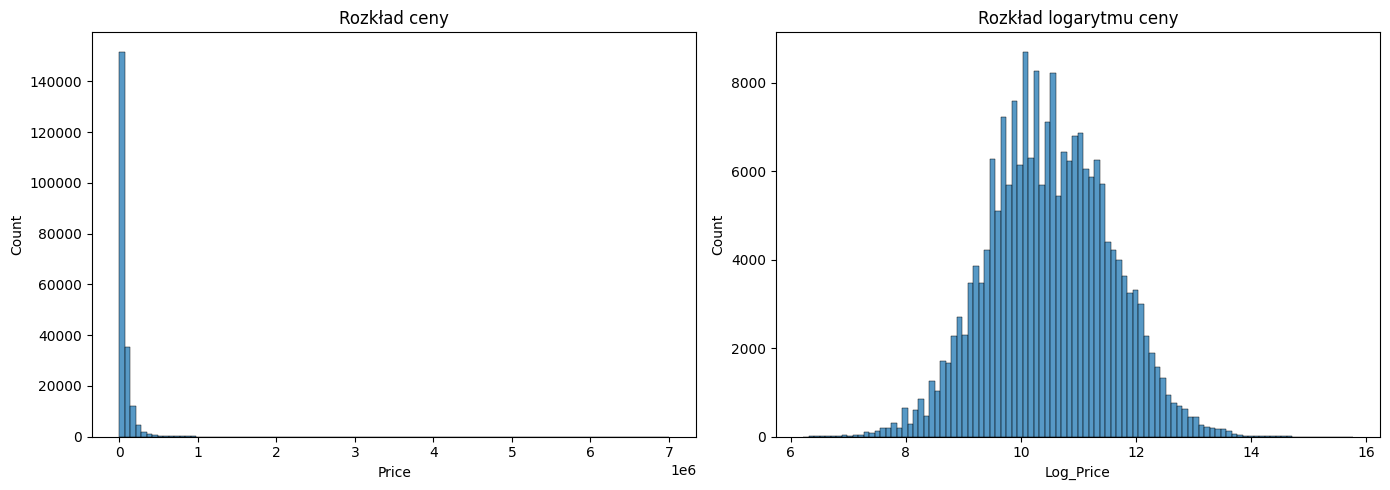

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["Price"], bins=100, ax=axes[0])
axes[0].set_title("Rozkład ceny")
axes[0].set_xlabel("Price")

sns.histplot(np.log(df["Price"]), bins=100, ax=axes[1])
axes[1].set_title("Rozkład logarytmu ceny")
axes[1].set_xlabel("Log_Price")

plt.tight_layout()

In [22]:
print("Waluta:")
print(df["Currency"].value_counts(dropna=False))

print("\nStan pojazdu:")
print(df["Condition"].value_counts(dropna=False))

print("\nNajpopularniejsze marki:")
print(df["Vehicle_brand"].value_counts().head(10))

Waluta:
Currency
PLN    208034
EUR       270
Name: count, dtype: int64

Stan pojazdu:
Condition
Used    182850
New      25454
Name: count, dtype: int64

Najpopularniejsze marki:
Vehicle_brand
Volkswagen       18455
BMW              16983
Audi             16730
Opel             16322
Ford             16007
Mercedes-Benz    12170
Renault          10702
Toyota           10206
Škoda            10166
Peugeot           9016
Name: count, dtype: int64


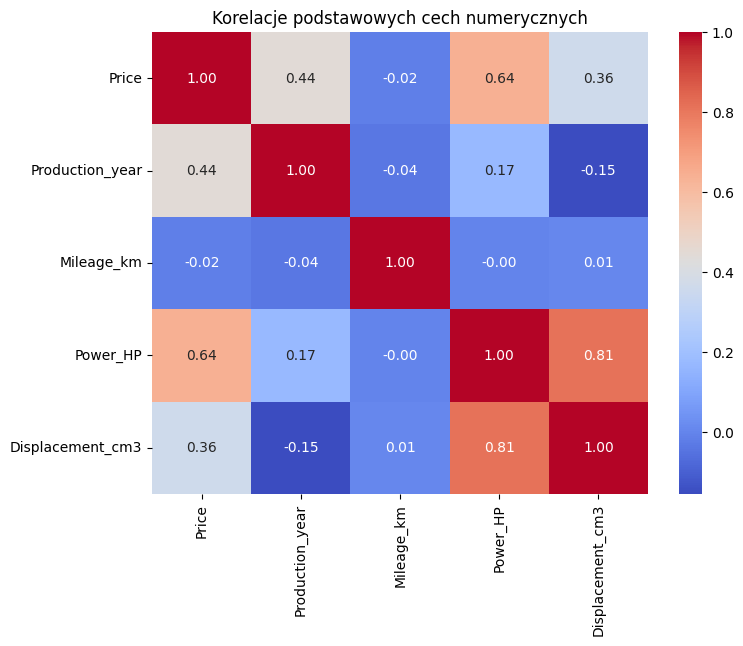

In [23]:
numeric_columns = ["Price", "Production_year", "Mileage_km", "Power_HP", "Displacement_cm3"]

plt.figure(figsize=(8, 6))
sns.heatmap(df[numeric_columns].corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Korelacje podstawowych cech numerycznych")
plt.show()

## 4. Preprocessing i inżynieria cech

Kroki są oparte na wcześniejszym notebooku z inżynierią cech:
- logarytmowanie ceny,
- usunięcie ofert w EUR,
- usunięcie outlierów ceny metodą IQR,
- usunięcie nietypowej liczby drzwi,
- połączenie marki i modelu w `Brand_Model`,
- target encoding dla marki i modelu,
- one-hot encoding wybranych zmiennych kategorycznych,
- rozbicie listy wyposażenia `Features`,
- skalowanie prostych zmiennych numerycznych.

Target encoding jest liczony wyłącznie na zbiorze treningowym, żeby ograniczyć leakage.

In [24]:
def clean_features(text):
    if pd.isna(text):
        return []
    try:
        parsed = ast.literal_eval(text)
        if isinstance(parsed, list):
            return [str(item).strip() for item in parsed if str(item).strip()]
    except (ValueError, SyntaxError):
        pass
    cleaned = str(text).replace("[", "").replace("]", "").replace("'", "").replace('"', "")
    return [item.strip() for item in cleaned.split(",") if item.strip()]


def remove_iqr_outliers(data, column):
    q1 = data[column].quantile(0.25)
    q3 = data[column].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    return data[(data[column] >= lower_bound) & (data[column] <= upper_bound)].copy()


def initial_preprocessing(data):
    data = data.copy()
    data["Log_Price"] = np.log(data["Price"])
    data = remove_iqr_outliers(data, "Log_Price")
    data = data[data["Currency"] != "EUR"].copy()
    data = data[data["Doors_number"].isna() | (data["Doors_number"] <= 7)].copy()
    data["Brand_Model"] = data["Vehicle_brand"] + " " + data["Vehicle_model"].fillna("")
    data["feat_list"] = data["Features"].apply(clean_features)
    return data

processed_df = initial_preprocessing(df)
print(f"Liczba rekordów po czyszczeniu: {len(processed_df)}")
processed_df[["Price", "Log_Price", "Vehicle_brand", "Vehicle_model", "Brand_Model", "feat_list"]].head()

Liczba rekordów po czyszczeniu: 206825


,Price,Log_Price,Vehicle_brand,Vehicle_model,Brand_Model,feat_list
0,86200,11.364425,Abarth,595,Abarth 595,[]
1,43500,10.680516,Abarth,Other,Abarth Other,[]
2,44900,10.712193,Abarth,500,Abarth 500,"[ABS, Electric front windows, Drivers airbag, ..."
3,39900,10.594132,Abarth,500,Abarth 500,"[ABS, Electric front windows, Drivers airbag, ..."
4,97900,11.491702,Abarth,595,Abarth 595,"[ABS, Electrically adjustable mirrors, Passeng..."


In [25]:
train_df, test_df = train_test_split(
    processed_df,
    test_size=0.2,
    random_state=RANDOM_STATE,
)

print(f"Train: {train_df.shape}")
print(f"Test: {test_df.shape}")

Train: (165460, 28)
Test: (41365, 28)


In [26]:
categorical_columns = ["Condition", "Fuel_type", "Drive", "Type", "Doors_number"]
numeric_columns = ["Production_year", "Mileage_km", "Power_HP", "Displacement_cm3"]
drop_columns = [
    "Index", "Vehicle_brand", "Vehicle_model", "Vehicle_version", "Vehicle_generation",
    "Brand_Model", "Currency", "Price", "CO2_emissions", "Transmission", "Colour",
    "Origin_country", "First_owner", "First_registration_date", "Offer_publication_date",
    "Offer_location", "Features", "feat_list"
]


def add_target_encoding(train, test, column, target_column="Log_Price"):
    global_mean = train[target_column].mean()
    mapping = train.groupby(column)[target_column].mean()
    train[f"{column}_Encoded"] = train[column].map(mapping).fillna(global_mean)
    test[f"{column}_Encoded"] = test[column].map(mapping).fillna(global_mean)
    return train, test


def build_feature_matrices(train, test):
    train = train.copy()
    test = test.copy()

    train, test = add_target_encoding(train, test, "Brand_Model")
    train, test = add_target_encoding(train, test, "Vehicle_brand")

    medians = train[numeric_columns].median(numeric_only=True)
    train[numeric_columns] = train[numeric_columns].fillna(medians)
    test[numeric_columns] = test[numeric_columns].fillna(medians)

    train_dummies = pd.get_dummies(train[categorical_columns], columns=categorical_columns, dummy_na=True)
    test_dummies = pd.get_dummies(test[categorical_columns], columns=categorical_columns, dummy_na=True)
    test_dummies = test_dummies.reindex(columns=train_dummies.columns, fill_value=0)

    mlb = MultiLabelBinarizer()
    train_features = pd.DataFrame(
        mlb.fit_transform(train["feat_list"]),
        columns=[f"feature_{name}" for name in mlb.classes_],
        index=train.index,
    )
    test_features = pd.DataFrame(
        mlb.transform(test["feat_list"]),
        columns=train_features.columns,
        index=test.index,
    )

    y_train = train["Log_Price"].copy()
    y_test = test["Log_Price"].copy()

    train_base = train.drop(columns=drop_columns + categorical_columns + ["Log_Price"], errors="ignore")
    test_base = test.drop(columns=drop_columns + categorical_columns + ["Log_Price"], errors="ignore")

    X_train = pd.concat([train_base, train_dummies, train_features], axis=1)
    X_test = pd.concat([test_base, test_dummies, test_features], axis=1)
    X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

    for column in numeric_columns:
        mean = X_train[column].mean()
        std = X_train[column].std()
        if std and std > 0:
            X_train[column] = (X_train[column] - mean) / std
            X_test[column] = (X_test[column] - mean) / std

    X_train = X_train.fillna(0).astype(float)
    X_test = X_test.fillna(0).astype(float)

    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = build_feature_matrices(train_df, test_df)

print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
X_train.head()

X_train: (165460, 112)
X_test: (41365, 112)


,Production_year,Mileage_km,Power_HP,Displacement_cm3,Brand_Model_Encoded,Vehicle_brand_Encoded,Condition_New,Condition_Used,Condition_nan,Fuel_type_Diesel,Fuel_type_Electric,Fuel_type_Ethanol,Fuel_type_Gasoline,Fuel_type_Gasoline + CNG,Fuel_type_Gasoline + LPG,Fuel_type_Hybrid,Fuel_type_Hydrogen,Fuel_type_nan,Drive_4x4 (attached automatically),Drive_4x4 (attached manually),Drive_4x4 (permanent),Drive_Front wheels,Drive_Rear wheels,Drive_nan,Type_SUV,Type_city_cars,Type_compact,Type_convertible,Type_coupe,Type_minivan,Type_sedan,Type_small_cars,Type_station_wagon,Type_nan,Doors_number_1.0,Doors_number_2.0,Doors_number_3.0,Doors_number_4.0,Doors_number_5.0,Doors_number_6.0,Doors_number_7.0,Doors_number_nan,feature_ABS,feature_ASR (traction control),feature_AUX socket,feature_Active cruise control,feature_Adjustable suspension,feature_Aftermarket radio,feature_Air curtains,feature_Airbag protecting the knees,feature_Alarm,feature_Alloy wheels,feature_Automatic air conditioning,feature_Auxiliary heating,feature_Blind spot sensor,feature_Bluetooth,feature_CD,feature_CD changer,feature_Central locking,feature_Cruise control,feature_DVD player,feature_Daytime running lights,feature_Drivers airbag,feature_Dual zone air conditioning,feature_ESP(stabilization of the track),feature_Electric front windows,feature_Electric rear windows,feature_Electrically adjustable mirrors,feature_Electrically adjustable seats,feature_Electrochromic rear view mirror,feature_Electrochromic side mirrors,feature_Factory radio,feature_Fog lights,feature_Four-zone air conditioning,feature_Front parking sensors,feature_Front side airbags,feature_GPS navigation,feature_HUD(head-up display),feature_Heated front seats,feature_Heated rear seats,feature_Heated side mirrors,feature_Heated windscreen,feature_Hook,feature_Immobilizer,feature_Isofix,feature_LED lights,feature_Lane assistant,feature_Leather upholstery,feature_MP3,feature_Manual air conditioning,feature_Multifunction steering wheel,feature_On-board computer,feature_Panoramic roof,feature_Parking assistant,feature_Passengers airbag,feature_Power steering,feature_Rain sensor,feature_Rear parking sensors,feature_Rear side airbags,feature_Rear view camera,feature_Roof rails,feature_SD socket,feature_Shift paddles,feature_Speed limiter,feature_Start-Stop system,feature_Sunroof,feature_TV tuner,feature_Tinted windows,feature_Twilight sensor,feature_USB socket,feature_Velor upholstery,feature_Xenon lights
44021,-0.163202,0.005950,-0.144736,0.169869,9.786359,10.036070,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
79096,0.851772,-0.047055,-0.413903,-0.108990,11.312124,10.573255,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0
40723,-0.453195,0.015909,-0.413903,-0.386447,10.069414,10.036070,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
30281,0.561780,-0.012622,2.277769,1.545944,11.489292,10.978909,0.0,1.

## 5. Trening modelu bazowego

Porównujemy:
- `DummyRegressor` jako punkt odniesienia,
- `Ridge` jako prosty baseline liniowy,
- `HistGradientBoostingRegressor` jako mocniejszy model bazowy z biblioteki scikit-learn,
- `LightGBM` jako docelowy szybki model gradient boosting do dalszego rozwoju projektu.

In [27]:
models = {
    "DummyRegressor": DummyRegressor(strategy="mean"),
    "Ridge": Ridge(alpha=1.0, random_state=RANDOM_STATE),
    "HistGradientBoostingRegressor": HistGradientBoostingRegressor(
        max_iter=200,
        learning_rate=0.08,
        max_leaf_nodes=31,
        random_state=RANDOM_STATE,
    ),
    "LightGBM": LGBMRegressor(
        n_estimators=500,
        learning_rate=0.05,
        num_leaves=64,
        max_depth=-1,
        subsample=0.9,
        colsample_bytree=0.9,
        objective="regression",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=-1,
    ),
}

fitted_models = {}

for name, model in models.items():
    print(f"Trening modelu: {name}")
    model.fit(X_train, y_train)
    fitted_models[name] = model

Trening modelu: DummyRegressor
Trening modelu: Ridge
Trening modelu: HistGradientBoostingRegressor
Trening modelu: LightGBM


## 6. Ewaluacja

Metryki liczymy dla logarytmu ceny oraz po powrocie do oryginalnej skali PLN.

In [28]:
def evaluate_model(model, X, y_log):
    pred_log = model.predict(X)
    y_price = np.exp(y_log)
    pred_price = np.exp(pred_log)
    return {
        "MAE_log": mean_absolute_error(y_log, pred_log),
        "RMSE_log": np.sqrt(mean_squared_error(y_log, pred_log)),
        "R2_log": r2_score(y_log, pred_log),
        "MAE_PLN": mean_absolute_error(y_price, pred_price),
        "RMSE_PLN": np.sqrt(mean_squared_error(y_price, pred_price)),
    }

results = []
for name, model in fitted_models.items():
    metrics = evaluate_model(model, X_test, y_test)
    metrics["model"] = name
    results.append(metrics)

results_df = pd.DataFrame(results).set_index("model").sort_values("R2_log", ascending=False)
results_df

,MAE_log,RMSE_log,R2_log,MAE_PLN,RMSE_PLN
model,,,,,
LightGBM,0.149092,0.226441,0.951044,7914.127980,17751.448709
HistGradientBoostingRegressor,0.161734,0.240910,0.944588,8841.793678,19631.434199
Ridge,0.286836,0.421928,0.830030,16542.742661,34486.340573
DummyRegressor,0.834618,1.023463,-0.000093,43103.708727,77117.499413


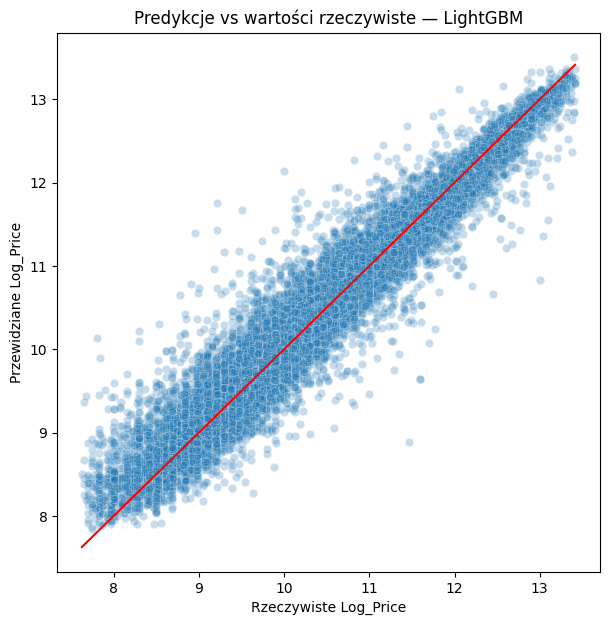

In [ ]:
best_model_name = results_df.index[0]
best_model = fitted_models[best_model_name]
pred_log = best_model.predict(X_test)

plt.figure(figsize=(7, 7))
sns.scatterplot(x=y_test, y=pred_log, alpha=0.25)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red")
plt.xlabel("Rzeczywiste Log_Price")
plt.ylabel("Przewidziane Log_Price")
plt.title(f"Predykcje vs wartości rzeczywiste - {best_model_name}")
plt.show()

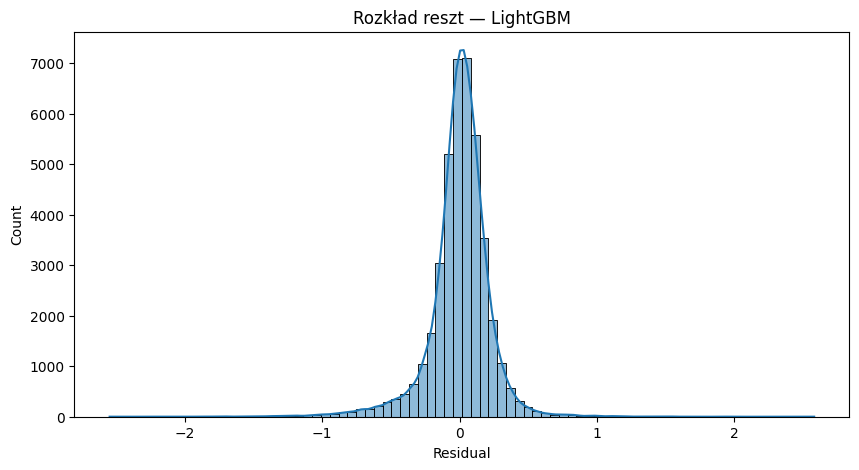

In [ ]:
residuals = y_test - pred_log

plt.figure(figsize=(10, 5))
sns.histplot(residuals, bins=80, kde=True)
plt.title(f"Rozkład reszt - {best_model_name}")
plt.xlabel("Residual")
plt.show()